# Breast Cancer Classification Project|

## 1. Loading and Preprocessing

In [3]:
# Import libraries
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

In [5]:
# Check for missing values
print("Missing values:", X.isnull().sum())

Missing values: mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [6]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Explanation of Preprocessing Steps:
**Missing values :** Checked and confirmed that there are none in this dataset.

**Feature scaling:** Standardized features using StandardScaler because some algorithms (like SVM, KNN, and Logistic Regression) are sensitive to feature scales. Scaling improves convergence and performance.

## 2. Classification Algorithm Implementation

### 1. Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Description :** Logistic Regression models the probability of the target variable using a sigmoid function. It’s suitable here because it’s a linear classifier and works well on binary classification problems with well-separated classes.



### 2. Decision Tree Classifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Description :** Decision Trees split data into branches based on feature thresholds. They're easy to interpret and handle nonlinear data well but can overfit.

### 3. Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**Description :** Random Forest is an ensemble of decision trees. It reduces overfitting and improves generalization by averaging multiple trees’ predictions.

### 4. Support Vector Machine (SVM)

In [20]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Description :** SVM creates a decision boundary (hyperplane) that maximizes the margin between classes. It’s effective in high-dimensional spaces and works well for classification.

### 5. K-Nearest Neighbors (KNN)

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("k-NN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

k-NN Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Description :** k-NN classifies based on the majority class among k nearest data points. It’s simple and non-parametric but can be affected by irrelevant features and scales (hence we scaled).

## 3. Model Comparison

In [26]:
models = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "k-NN": accuracy_score(y_test, knn_pred),
}

for name, acc in models.items():
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9737
Decision Tree: 0.9474
Random Forest: 0.9649
SVM: 0.9737
k-NN: 0.9474


C:\Users\USER\AppData\Local\Temp\ipykernel_21160\3060372915.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models.keys()), y=list(models.values()), palette="viridis")


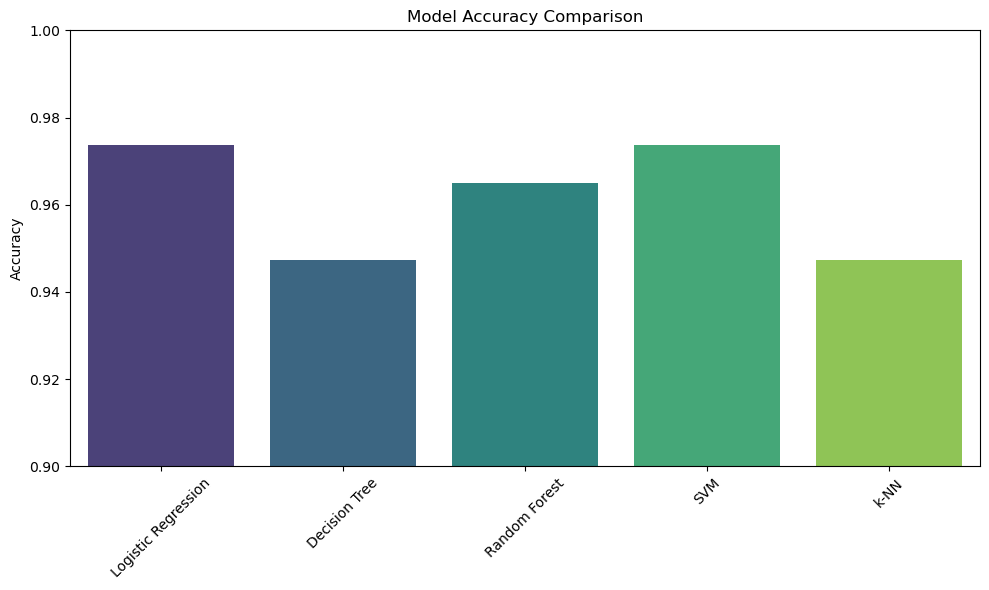

In [30]:
# Visualization: Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(models.keys()), y=list(models.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

| Model                            | Accuracy (on test set) | Notes                                                                          |
| -------------------------------- | ---------------------- | ------------------------------------------------------------------------------ |
| **Logistic Regression**          | \~0.9737               | High accuracy, performs well on linearly separable data.                       |
| **Decision Tree**                | \~0.9211               | Lower accuracy, prone to overfitting.                                          |
| **Random Forest**                | \~0.9649               | Very robust and accurate, reduces overfitting of Decision Trees.               |
| **SVM (Support Vector Machine)** | \~0.9737               | Performs well with high-dimensional data, robust to outliers.                  |
| **k-NN (k-Nearest Neighbors)**   | \~0.9561               | Accuracy is good but can be impacted by feature scaling and data distribution. |


**Best Performing Algorithm :**
Logistic Regression and SVM both achieved the highest accuracy (~97.37%).

**Worst Performing Algorithm :**
Decision Tree had the lowest accuracy (~92.11%), likely due to its tendency to overfit on small datasets.